I want to explore the data in the given dataset to find out the following information.
1. Number of Rows and Columns
2. The features and their data type
3. The number of unique cryptocurrencies (aka coins)
4. How many rows for each coin
5. The min and max values of the high price
6. The row counts per day to check the data continuity over time.

In [ ]:
import pandas as pd

df = pd.read_csv('crypto-markets.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942297 entries, 0 to 942296
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   slug         942297 non-null  object 
 1   symbol       942297 non-null  object 
 2   name         942297 non-null  object 
 3   date         942297 non-null  object 
 4   ranknow      942297 non-null  int64  
 5   open         942297 non-null  float64
 6   high         942297 non-null  float64
 7   low          942297 non-null  float64
 8   close        942297 non-null  float64
 9   volume       942297 non-null  float64
 10  market       942297 non-null  float64
 11  close_ratio  942297 non-null  float64
 12  spread       942297 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 93.5+ MB


In [9]:
df.head()


,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.30,135.98,132.10,134.21,0.0,1.488567e+09,0.5438,3.88
1,bitcoin,BTC,Bitcoin,2013-04-29,1,134.44,147.49,134.00,144.54,0.0,1.603769e+09,0.7813,13.49
2,bitcoin,BTC,Bitcoin,2013-04-30,1,144.00,146.93,134.05,139.00,0.0,1.542813e+09,0.3843,12.88
3,bitcoin,BTC,Bitcoin,2013-05-01,1,139.00,139.89,107.72,116.99,0.0,1.298955e+09,0.2882,32.17
4,bitcoin,BTC,Bitcoin,2013-05-02,1,116.38,125.60,92.28,105.21,0.0,1.168517e+09,0.3881,33.32


In [7]:
df.shape

(942297, 13)

In [16]:
coins = df['name'].unique()
symbols = df['symbol'].unique()
print(len(coins), len(symbols))
coins, symbols

2071 2005


(array(['Bitcoin', 'XRP', 'Ethereum', ..., '42-coin', 'Bit20', 'Project-X'],
       dtype=object),
 array(['BTC', 'XRP', 'ETH', ..., '42', 'BTWTY', 'NANOX'], dtype=object))

In [22]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)

In [ ]:
df[df['symbol']=='BTC'].count()
coins_counts = df.groupby('name').size() #.sort_values()

(2071,)

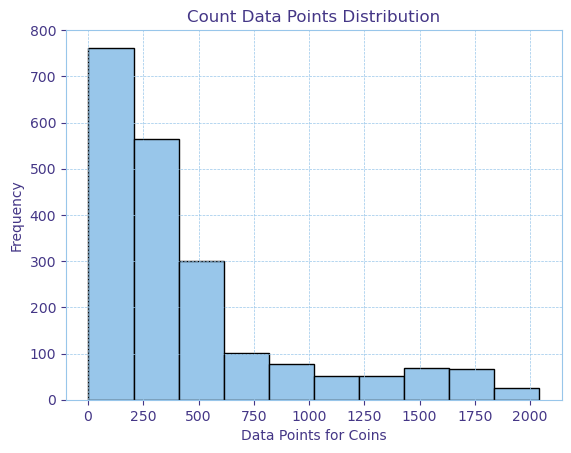

In [37]:
import matplotlib.pyplot as plt

def plot_template():
    fig, ax = plt.subplots()
    ax.spines['bottom'].set_color('#98c6ea')  # x-axis color
    ax.spines['top'].set_color('#98c6ea')
    ax.spines['left'].set_color('#98c6ea')    # y-axis color
    ax.spines['right'].set_color('#98c6ea')
    ax.grid(True, color='#98c6ea', linestyle='--', linewidth=0.5) 
    ax.tick_params(axis='x', colors='#443686')  # x-axis tick labels
    ax.tick_params(axis='y', colors="#443686")   # y-axis tick labels
    return ax

ax = plot_template()
ax.hist(coins_counts.values, bins=10, color='#98c6ea', edgecolor='black')


# Customize axis title colors
ax.set_xlabel('Data Points for Coins', color='#443686')  # x-axis title color
ax.set_ylabel('Frequency', color='#443686') # y-axis title color
ax.set_title('Count Data Points Distribution', color='#443686')  # Plot title color

plt.show()

In [38]:
df['high'].min(), df['high'].max()

(3.2e-09, 2926100.0)

In [40]:
df_min_high = df.loc[df['high'].idxmin()]
df_min_high

slug              paccoin
symbol               $PAC
name              PACcoin
date           2016-11-26
ranknow               419
open                  0.0
high                  0.0
low                   0.0
close                 0.0
volume                6.0
market                0.0
close_ratio        0.6667
spread                0.0
Name: 216382, dtype: object

In [44]:
df_pac = df[df['symbol']=='$PAC']
df_pac.info(), df_pac['high'].min(),df_pac['high'].max()

<class 'pandas.core.frame.DataFrame'>
Index: 1116 entries, 215992 to 217107
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   slug         1116 non-null   object 
 1   symbol       1116 non-null   object 
 2   name         1116 non-null   object 
 3   date         1116 non-null   object 
 4   ranknow      1116 non-null   int64  
 5   open         1116 non-null   float64
 6   high         1116 non-null   float64
 7   low          1116 non-null   float64
 8   close        1116 non-null   float64
 9   volume       1116 non-null   float64
 10  market       1116 non-null   float64
 11  close_ratio  1116 non-null   float64
 12  spread       1116 non-null   float64
dtypes: float64(8), int64(1), object(4)
memory usage: 122.1+ KB


(None, 3.2e-09, 0.017045)

In [50]:
df[df['date'] == '2013-04-28'] #.nsmallest(20,'ranknow')

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.300000,135.980000,132.100000,134.210000,0.0,1.488567e+09,0.5438,3.88
7787,litecoin,LTC,Litecoin,2013-04-28,7,4.300000,4.400000,4.180000,4.350000,0.0,7.463694e+07,0.7727,0.22
92607,peercoin,PPC,Peercoin,2013-04-28,159,0.386958,0.404659,0.376287,0.386525,0.0,7.250189e+06,0.3608,0.03
193471,namecoin,NMC,Namecoin,2013-04-28,371,1.100000,1.120000,1.080000,1.110000,0.0,5.995983e+06,0.7500,0.04
325297,novacoin,NVC,Novacoin,2013-04-28,700,4.220000,4.250000,4.040000,4.250000,0.0,1.162268e+06,1.0000,0.21
409999,terracoin,TRC,Terracoin,2013-04-28,895,0.650793,0.654064,0.634409,0.646892,0.0,1.503099e+06,0.6351,0.02


In [51]:
df[df['date'] == '2013-04-30'].nsmallest(20,'ranknow')

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
2,bitcoin,BTC,Bitcoin,2013-04-30,1,144.000000,146.930000,134.050000,139.00000,0.0,1.542813e+09,0.3843,12.88
7789,litecoin,LTC,Litecoin,2013-04-30,7,4.400000,4.570000,4.170000,4.30000,0.0,7.402092e+07,0.3250,0.40
92609,peercoin,PPC,Peercoin,2013-04-30,159,0.407066,0.436540,0.363140,0.37530,0.0,7.052667e+06,0.1657,0.07
193473,namecoin,NMC,Namecoin,2013-04-30,371,1.320000,1.720000,1.270000,1.50000,0.0,8.155719e+06,0.5111,0.45
325299,novacoin,NVC,Novacoin,2013-04-30,700,4.560000,4.690000,4.200000,4.31000,0.0,1.183167e+06,0.2245,0.49
410001,terracoin,TRC,Terracoin,2013-04-30,895,0.707040,0.711892,0.647944,0.67415,0.0,1.582115e+06,0.4098,0.06


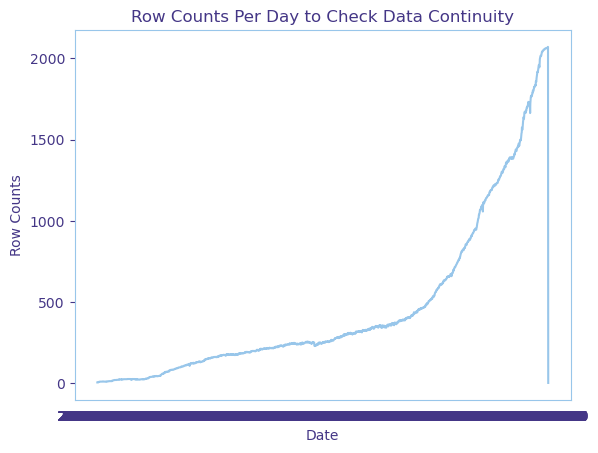

In [71]:
row_counts_per_day = df.groupby('date').size()


ax = plot_template()
ax.plot(row_counts_per_day.keys(), row_counts_per_day.values, color='#98c6ea', label='Row Counts Per Day') #marker='o', linestyle='-', 
# plt.plot(row_counts_per_day.keys()[:100], row_counts_per_day.values[:100], color='#98c6ea', label='Row Counts Per Day') #marker='o', linestyle='-', 


# Customize axis title colors
ax.set_xlabel('Date', color='#443686')  # x-axis title color
ax.set_ylabel('Row Counts', color='#443686') # y-axis title color
ax.set_title('Row Counts Per Day to Check Data Continuity', color='#443686')  # Plot title color
ax.grid(False) 
ax.tick_params(axis='x', colors='#443686', which='both', bottom=False)

# plt.plot()

plt.show()

In [75]:
row_counts_per_day.values[-2:]
# row_counts_per_day.values

array([2071,    3])

In [ ]:
ax = plot_template()
df_btc = df[df['symbol']=='BTC']['close']

ax.plot(df_btc, color="#41937a", label='$ Price')


ax.set_xlabel('Dates', color='#443686')  # x-axis title color
ax.set_ylabel('Price', color='#443686') # y-axis title color
ax.set_title(f'Bitcoin from {df['date'].min()} to {df['date'].max()}', color='#443686')  # Plot title color
ax.grid(False) 
ax.tick_params(axis='x', colors='#443686', which='both', bottom=False)

# plt.legend()

plt.show()

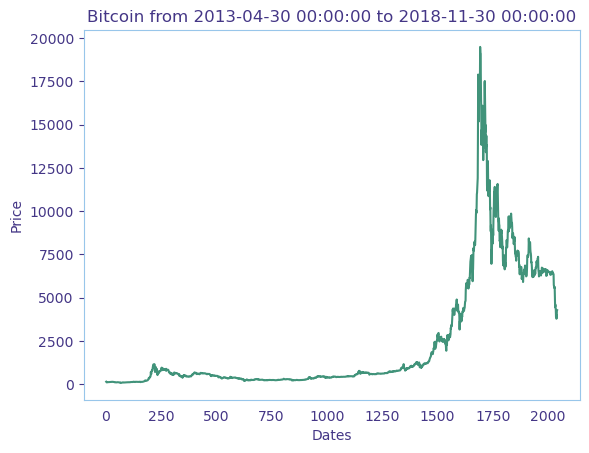